In [1]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes
def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list

# Function to get meal, snack, and mega meal metrics, including mega_meal_frequency and mega_meal_size
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0, [], [])

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    IMIs = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:  # Make sure we are within the 7-day boundary
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 4:
                meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 5:
                mega_meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            IMIs.append(ipi)  # Store IMI as a list of timestamps
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        day_index = int(current_event[0] // 24)
        hour = int(current_event[0]) % 24
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)  # Add the number of mega meals

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals, IPIs, IMIs)


# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Load the metafile and process the data
metafile = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

        # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"],
        mice[key]["grain_ipi"],       # IPI for grain phase
        mice[key]["grain_imi"]        # IMI for grain phase
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"],
        mice[key]["pr_ipi"],          # IPI for PR phase
        mice[key]["pr_imi"]           # IMI for PR phase
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"],
        mice[key]["nr_ipi"],          # IPI for NR phase
        mice[key]["nr_imi"]           # IMI for NR phase
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)

# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])
    print("  IPI for Grain phase:", mice[key]["grain_ipi"])
    print("  IMI for Grain phase:", mice[key]["grain_imi"])
    print("  IPI for PR phase:", mice[key]["pr_ipi"])
    print("  IMI for PR phase:", mice[key]["pr_imi"])
    print("  IPI for NR phase:", mice[key]["nr_ipi"])
    print("  IMI for NR phase:", mice[key]["nr_imi"])



Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [43, 25, 23, 35, 28, 31, 24, 24, 31, 14, 9, 18, 18, 15, 13, 9, 6]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 2, 1, 0, 1, 0, 2, 1, 1, 1, 1, 2, 3, 3, 1, 2, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 2, 1, 2, 3, 3, 2, 1, 2, 0, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0, 1, 0, 0, 3], [0, 2, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 3, 3, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 1, 4, 2, 3, 2, 0, 1, 0, 1, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 2, 2, 3, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 1.0133227626203154
  Mega Meals Size: 7.27810650887574
  IPI for Grain phase: [2.77777778e-04 5.55555556e-04 2.77777778e-04 2.77777778e-04
 7.13

6 items in output dictionary


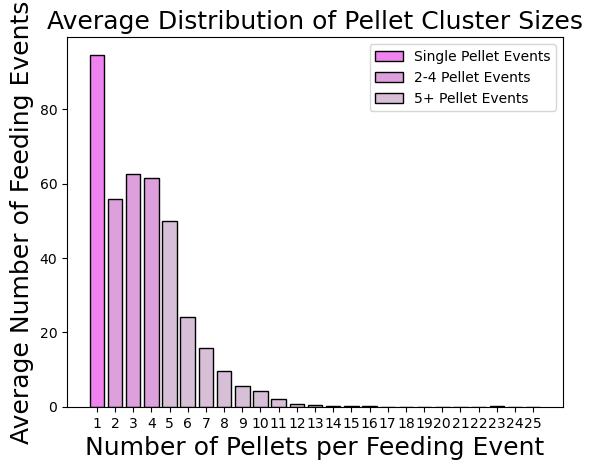

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def flatten_list(nested_list):
    """Helper function to flatten a list of lists into a single list."""
    return [item for sublist in nested_list for item in sublist]

def cluster_pellets_by_ipi(pellettimes, ipi_threshold=60):
    """
    Cluster pellet events based on inter-pellet interval (IPI).
    Parameters
    ----------
    pellettimes : list of timestamps (in seconds)
        Times when each pellet was taken.
    ipi_threshold : float
        Threshold for defining clusters based on IPI (in seconds). Default is 60 seconds.
    
    Returns
    -------
    clusters : list of lists
        Each sublist contains the timestamps of pellets within a cluster.
    """
    pellettimes = np.array(sorted(pellettimes))* 3600  # Convert from hours to seconds and sort

    IPIs = np.diff(pellettimes)  # Calculate time differences between consecutive pellets

    # Initialize clusters
    clusters = []
    current_cluster = [pellettimes[0]]  # Start with the first pellet

    for i, ipi in enumerate(IPIs):
        if ipi <= ipi_threshold:
            current_cluster.append(pellettimes[i + 1])
        else:
            clusters.append(current_cluster)
            current_cluster = [pellettimes[i + 1]]

    if current_cluster:
        clusters.append(current_cluster)

    return clusters

def get_cluster_size_distribution_for_mouse(pellettimes):
    """
    Get the cluster size distribution for a single mouse.
    Parameters
    ----------
    pellettimes : list of timestamps (in seconds)
        Times when each pellet was taken.
    
    Returns
    -------
    cluster_sizes : list
        The number of pellets in each cluster for this mouse.
    """
    clusters = cluster_pellets_by_ipi(pellettimes)
    cluster_sizes = [len(cluster) for cluster in clusters]
    return cluster_sizes

def average_cluster_sizes_across_mice(pellettimes_group, max_pellets_per_event=10):
    """
    Calculate the average cluster size distribution across multiple mice.
    Parameters
    ----------
    pellettimes_group : list of lists
        A list of timestamp lists for each mouse.
    max_pellets_per_event : int
        The maximum number of pellets per event to include in the analysis.
    
    Returns
    -------
    avg_cluster_sizes : list
        The average number of events for each cluster size (1 pellet, 2 pellets, etc.).
    """
    # Initialize the counts for each pellet size
    total_cluster_counts = np.zeros(max_pellets_per_event)

    # Loop over each mouse and calculate cluster size distribution
    for pellettimes in pellettimes_group:
        cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
        for size in cluster_sizes:
            if size <= max_pellets_per_event:
                total_cluster_counts[size - 1] += 1
            else:
                # If size exceeds max_pellets_per_event, add to the last bin
                total_cluster_counts[-1] += 1

    # Calculate the average cluster size distribution across mice
    avg_cluster_sizes = total_cluster_counts / len(pellettimes_group)
    
    return avg_cluster_sizes

def plot_average_cluster_size_distribution(avg_cluster_sizes, max_pellets_per_event=25):
    """
    Plot the average cluster size distribution across multiple mice with custom colors.
    Parameters
    ----------
    avg_cluster_sizes : list
        The average number of events for each cluster size (1 pellet, 2 pellets, etc.).
    max_pellets_per_event : int
        The maximum number of pellets per event included in the analysis.
    """
    f, ax = plt.subplots()

    bins = np.arange(1, max_pellets_per_event + 1)

    # Define colors based on cluster sizes
    colors = []
    for size in bins:
        if size == 1:
            colors.append('violet')  # 1-pellet events
        elif 2 <= size <= 4:
            colors.append('plum')   # 2-4-pellet events
        else:
            colors.append('thistle') # 5+ pellet events

    # Plot the bar chart with custom colors
    ax.bar(bins, avg_cluster_sizes, color=colors, edgecolor='black')

    ax.set_ylabel('Average Number of Feeding Events', fontsize=18)
    ax.set_xlabel('Number of Pellets per Feeding Event', fontsize=18)
    ax.set_xticks(bins)
    ax.set_title('Average Distribution of Pellet Cluster Sizes', fontsize=18)

    # Add legend to explain the colors
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='violet', edgecolor='black', label='Single Pellet Events'),
                       Patch(facecolor='plum', edgecolor='black', label='2-4 Pellet Events'),
                       Patch(facecolor='thistle', edgecolor='black', label='5+ Pellet Events')]
    ax.legend(handles=legend_elements)

    ax.grid(False)
    plt.show()

nrpr_male_selector = {"order": 1, "sex": "M"}
pellettimes_group = get_data_fields(mice, ["nr_timestamps"], nrpr_male_selector)  # Get the timestamps for each mouse

# Calculate the average cluster size distribution across mice
avg_cluster_sizes = average_cluster_sizes_across_mice(pellettimes_group, max_pellets_per_event=25)

# Plot the average distribution of cluster sizes with custom colors
plot_average_cluster_size_distribution(avg_cluster_sizes, max_pellets_per_event=25)


In [4]:
def get_cluster_size_counts(cluster_sizes, max_pellets_per_event=25):
    sizes = np.arange(1, max_pellets_per_event + 1)
    counts = np.zeros_like(sizes, dtype=int)
    for size in cluster_sizes:
        if size <= max_pellets_per_event:
            counts[size - 1] += 1
        else:
            counts[-1] += 1
    return sizes, counts


In [5]:
def exponential_decay(x, a, b):
    return a * np.exp(-b * x)


In [6]:
from scipy.optimize import curve_fit

def fit_exponential_decay(sizes, counts):
    # Remove zeros to avoid log(0)
    mask = counts > 0
    sizes = sizes[mask]
    counts = counts[mask]

    if len(sizes) < 2:
        # Not enough data to fit
        return None, None

    # Log-transform the counts
    log_counts = np.log(counts)

    # Fit a linear function to the log-transformed data
    def linear_func(x, a, b):
        return a + b * x

    popt, pcov = curve_fit(linear_func, sizes, log_counts)
    a = np.exp(popt[0])
    b = -popt[1]
    return (a, b), pcov


In [7]:
for mouse_id in mice:
    # Select the phase you're interested in (e.g., NR phase)
    pellettimes = mice[mouse_id].get("nr_timestamps", [])
    if not pellettimes:
        continue

    # Get cluster sizes
    cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)

    # Get counts of each cluster size
    sizes, counts = get_cluster_size_counts(cluster_sizes)

    # Fit exponential decay
    params, pcov = fit_exponential_decay(sizes, counts)
    if params is not None:
        a, b = params
        mice[mouse_id]['exp_fit_params_nr'] = {'a': a, 'b': b}
    else:
        print(f"Not enough data to fit for mouse {mouse_id} in NR phase")


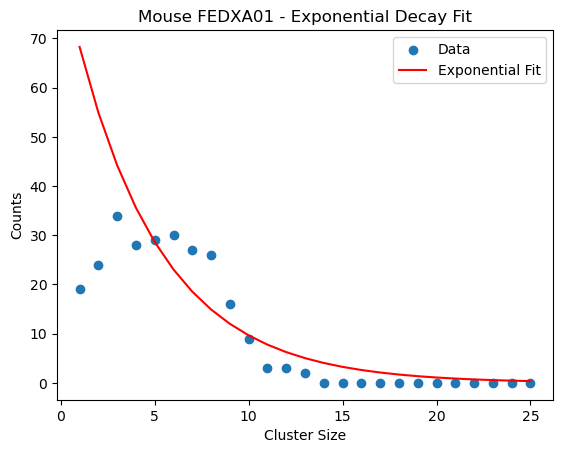

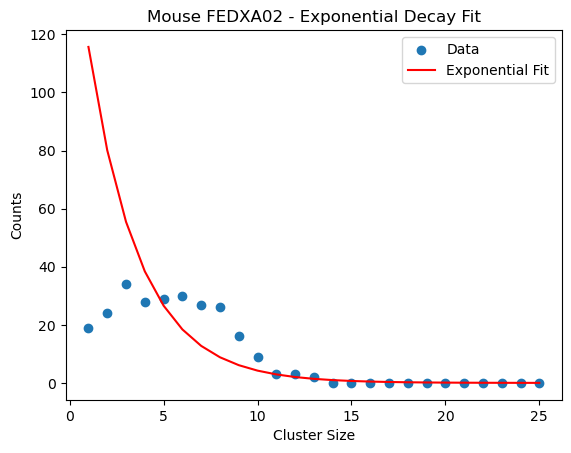

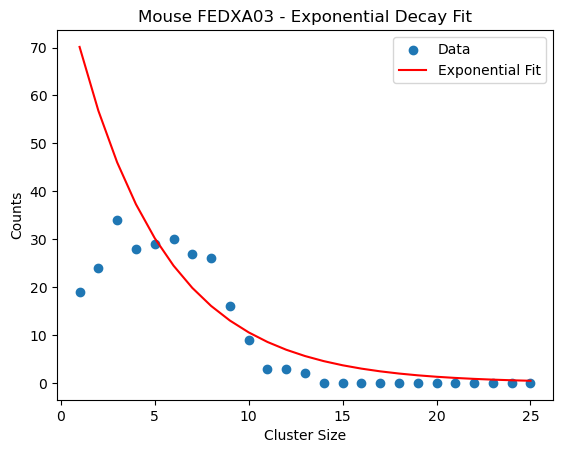

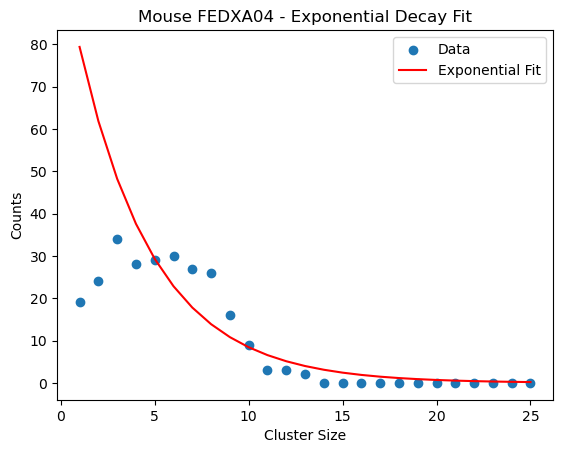

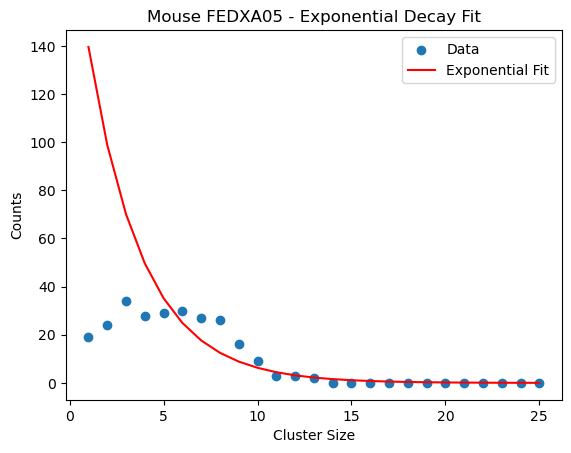

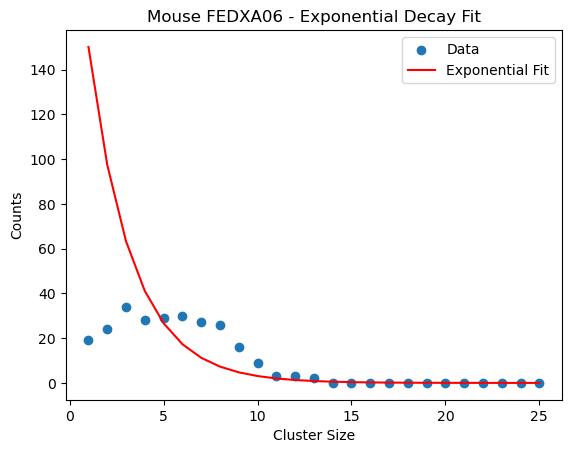

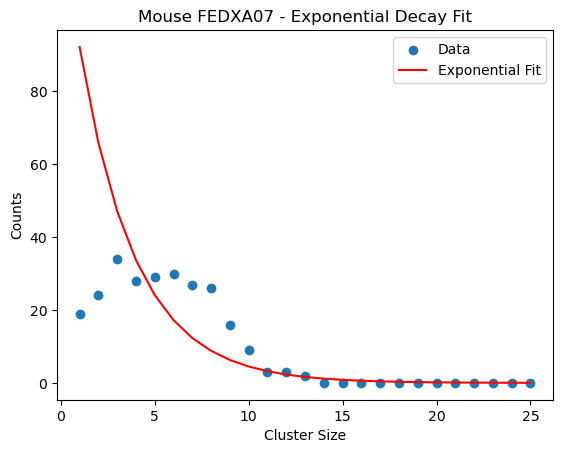

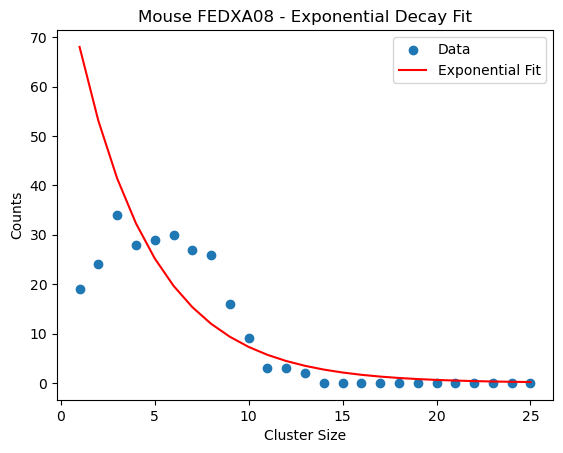

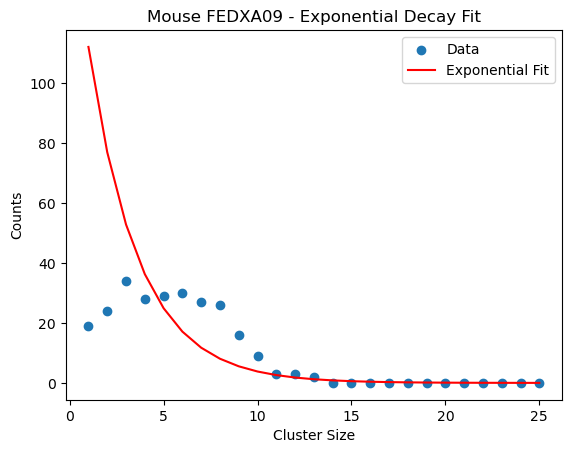

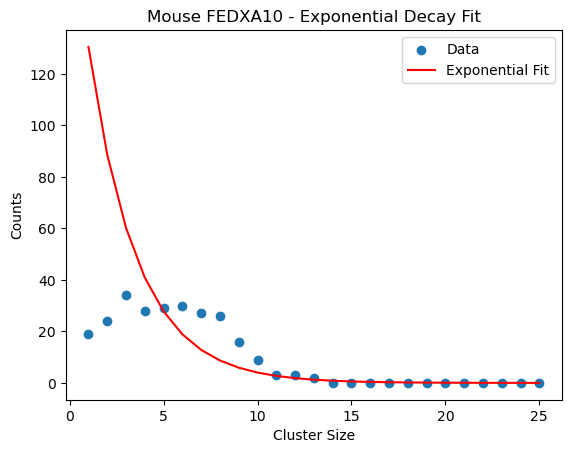

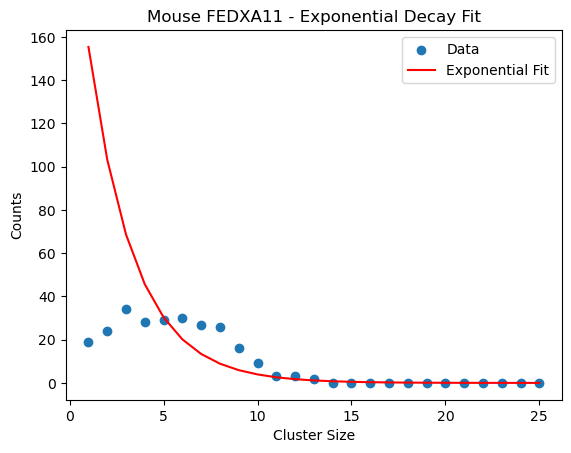

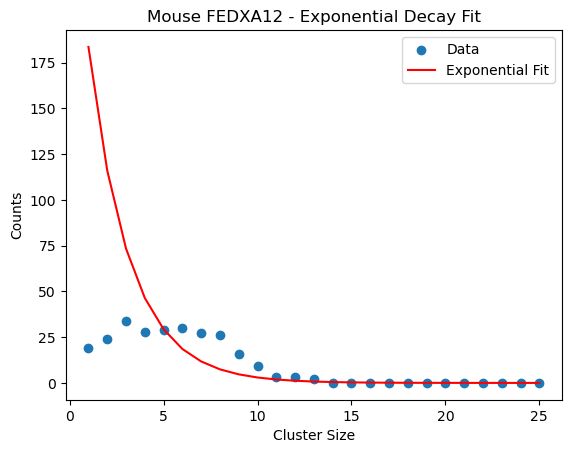

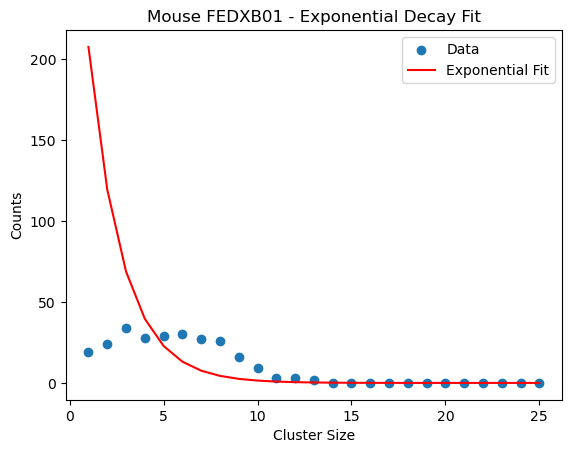

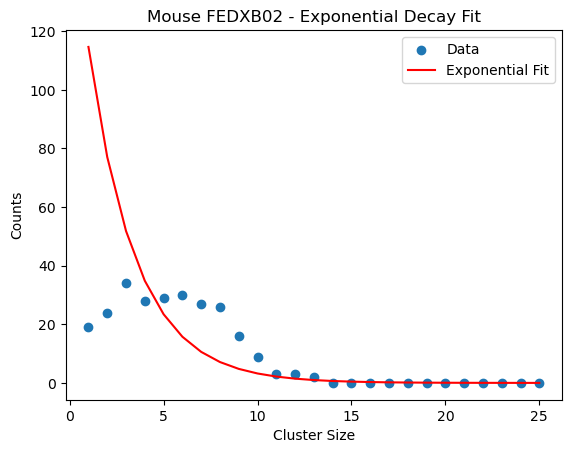

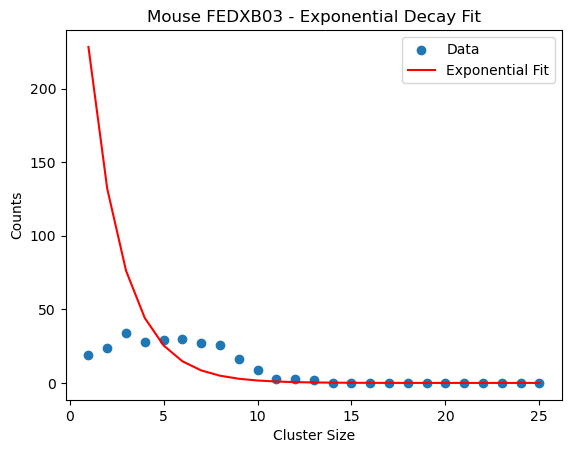

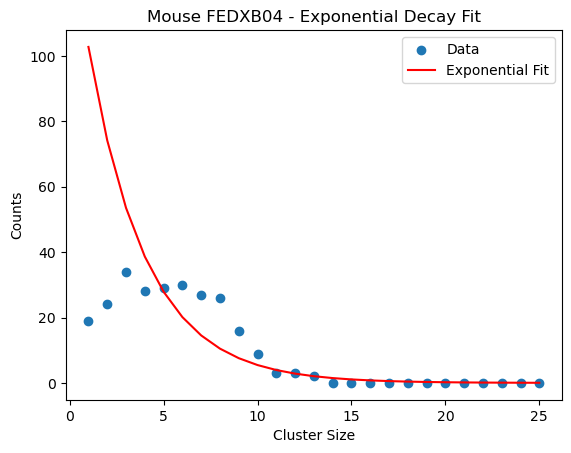

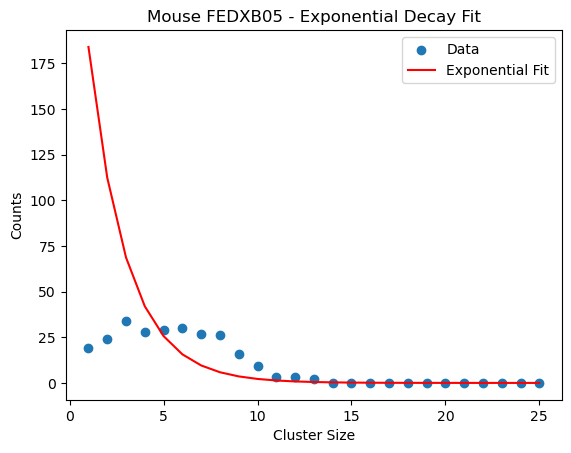

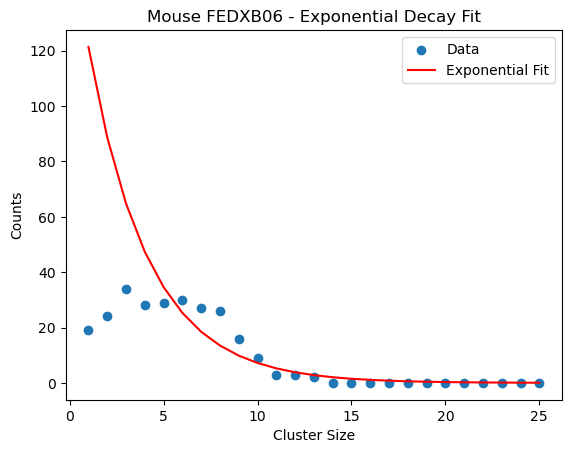

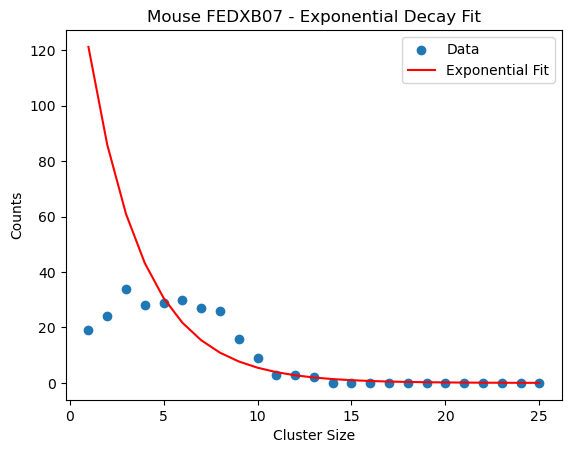

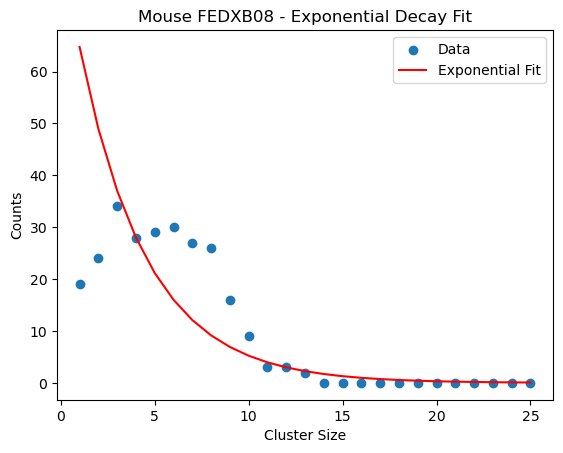

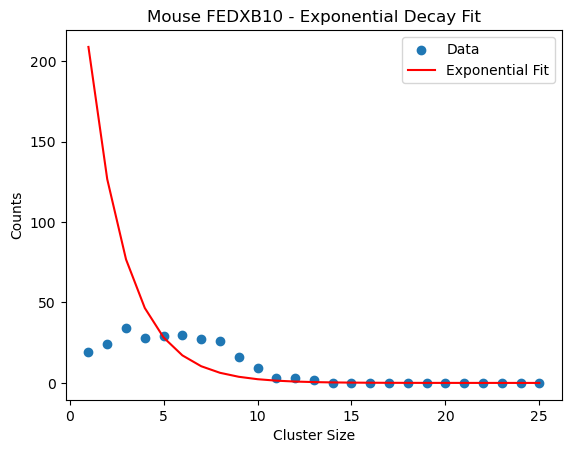

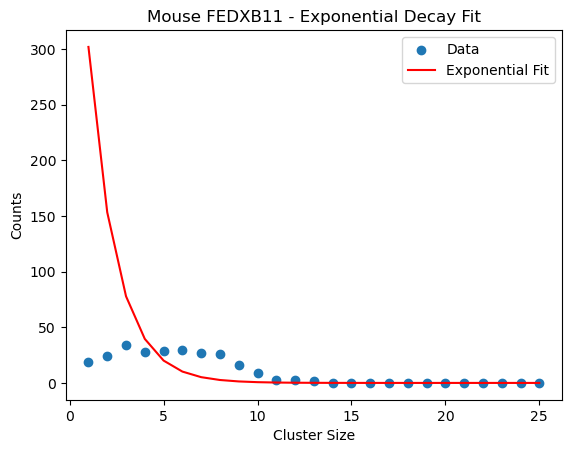

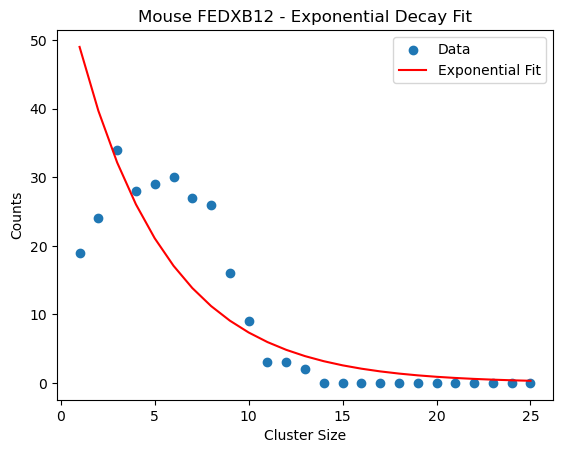

In [8]:
import matplotlib.pyplot as plt

for mouse_id in mice:
    params = mice[mouse_id].get('exp_fit_params_nr', None)
    if params:
        a, b = params['a'], params['b']
        sizes, counts = get_cluster_size_counts(cluster_sizes)

        plt.figure()
        plt.scatter(sizes, counts, label='Data')
        plt.plot(sizes, exponential_decay(sizes, a, b), label='Exponential Fit', color='red')
        plt.xlabel('Cluster Size')
        plt.ylabel('Counts')
        plt.title(f'Mouse {mouse_id} - Exponential Decay Fit')
        plt.legend()
        plt.show()


# Making sure the cluster size is correctly measured and plotted ---  the pellet_times was not correctly measured in the loop for each mouse

In [11]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Function to read FED events
def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        pellettimes.append(Deltatinseconds)

    return pellettimes

# Function to get a subset of data based on selectors
def get_data_subset(dictionary, selectors=None, verbose=True):
    if selectors is None or len(selectors) == 0:
        if verbose:
            print("{} items in output dictionary (no selectors applied)".format(len(dictionary.keys())))
        return dictionary.copy()

    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in list(output_dictionary.keys()):
            try:
                mouse_value = output_dictionary[mouse_id][key]
                if isinstance(value, list):
                    if mouse_value not in value:
                        output_dictionary.pop(mouse_id)
                else:
                    if mouse_value != value:
                        output_dictionary.pop(mouse_id)
            except KeyError:
                pass

    if verbose:
        print("{} items in output dictionary after applying selectors".format(len(output_dictionary.keys())))

    return output_dictionary

# Function to get specific fields from the data
def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list

# Function to get meal, snack, and mega meal metrics
def get_meal_and_snack_metrics(pellettimes, meal_threshold=60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, [], [], [], 0, [], [])

    # Sort pellettimes in seconds
    pellettimes = np.array(sorted(pellettimes))
    IPIs = np.diff(pellettimes)
    meals = []
    snacks = []
    mega_meals = []
    IMIs = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            event_start_time = current_event[0]
            day_index = int(event_start_time // (24 * 3600))
            hour = int((event_start_time % (24 * 3600)) // 3600)
            if len(current_event) == 1:
                snacks.append(current_event)
                if day_index < 7:
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 4:
                meals.append(current_event)
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 5:
                mega_meals.append(current_event)
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            IMIs.append(ipi)
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        event_start_time = current_event[0]
        day_index = int(event_start_time // (24 * 3600))
        hour = int((event_start_time % (24 * 3600)) // 3600)
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = (max(pellettimes) - min(pellettimes)) / 3600  # Convert to hours
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals, IPIs, IMIs)

# Function to get events per day
def get_events_per_day(events, days=7):
    events_per_day = [0] * days
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // (24 * 3600))
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        start_time = day * 24 * 3600
        end_time = (day + 1) * 24 * 3600
        pellets = [t for t in timestamps if (t >= start_time) and (t < end_time)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day

# Function to cluster pellets by IPI
def cluster_pellets_by_ipi(pellettimes, ipi_threshold=60):
    pellettimes = np.array(sorted(pellettimes))  # Times in seconds
    IPIs = np.diff(pellettimes)
    clusters = []
    current_cluster = [pellettimes[0]]

    for i, ipi in enumerate(IPIs):
        if ipi <= ipi_threshold:
            current_cluster.append(pellettimes[i + 1])
        else:
            clusters.append(current_cluster)
            current_cluster = [pellettimes[i + 1]]

    if current_cluster:
        clusters.append(current_cluster)

    return clusters

# Function to get cluster size distribution for a mouse
def get_cluster_size_distribution_for_mouse(pellettimes):
    clusters = cluster_pellets_by_ipi(pellettimes)
    cluster_sizes = [len(cluster) for cluster in clusters]
    return cluster_sizes

# Function to get counts of cluster sizes
def get_cluster_size_counts(cluster_sizes, max_pellets_per_event=25):
    sizes = np.arange(1, max_pellets_per_event + 1)
    counts = np.zeros_like(sizes, dtype=int)
    for size in cluster_sizes:
        if size <= max_pellets_per_event:
            counts[size - 1] += 1
        else:
            counts[-1] += 1
    return sizes, counts

# Exponential decay function
def exponential_decay(x, a, b):
    return a * np.exp(-b * x)

# Function to fit exponential decay
def fit_exponential_decay(sizes, counts):
    # Remove zeros to avoid log(0)
    mask = counts > 0
    sizes = sizes[mask]
    counts = counts[mask]

    if len(sizes) < 2:
        # Not enough data to fit
        return None, None

    # Log-transform the counts
    log_counts = np.log(counts)

    # Fit a linear function to the log-transformed data
    def linear_func(x, a, b):
        return a + b * x

    popt, pcov = curve_fit(linear_func, sizes, log_counts)
    a = np.exp(popt[0])
    b = -popt[1]
    return (a, b), pcov

# Function to perform exponential decay fitting for all phases
def fit_exponential_decay_for_all_phases(mice, phases=['grain', 'pr', 'nr'], max_pellets_per_event=15):
    for mouse_id in mice:
        for phase in phases:
            pellettimes = mice[mouse_id].get(f"{phase}_timestamps", [])
            if not pellettimes:
                continue
            # Get cluster sizes
            cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
            # Get counts of each cluster size
            sizes, counts = get_cluster_size_counts(cluster_sizes, max_pellets_per_event)
            # Fit exponential decay
            params, pcov = fit_exponential_decay(sizes, counts)
            if params is not None:
                a, b = params
                mice[mouse_id][f'exp_fit_params_{phase}'] = {'a': a, 'b': b}
            else:
                print(f"Not enough data to fit for mouse {mouse_id} in {phase.upper()} phase")

# Function to save results to CSV
def save_results_to_csv(mice, filename='exponential_decay_results.csv'):
    # Prepare the data
    data_list = []
    for mouse_id, mouse_data in mice.items():
        order = mouse_data.get('order', 'NA')
        sex = mouse_data.get('sex', 'NA')
        for phase in ['grain', 'pr', 'nr']:
            exp_params = mouse_data.get(f'exp_fit_params_{phase}', None)
            if exp_params:
                a = exp_params['a']
                b = exp_params['b']
                data_list.append({
                    'mouse_id': mouse_id,
                    'order': order,
                    'sex': sex,
                    'diet_phase': phase.upper(),
                    'a': a,
                    'b': b
                })
    # Write to CSV
    with open(filename, mode='w', newline='') as csv_file:
        fieldnames = ['mouse_id', 'order', 'sex', 'diet_phase', 'a', 'b']
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
        writer.writeheader()
        for data in data_list:
            writer.writerow(data)
    print(f"Results saved to {filename}")

# Function to visualize the cluster size distribution and fit
def visualize_cluster_size_distribution(mouse_id, phase, mice, max_pellets_per_event=25):
    exp_params = mice[mouse_id].get(f'exp_fit_params_{phase}', None)
    if exp_params:
        a = exp_params['a']
        b = exp_params['b']
        pellettimes = mice[mouse_id].get(f"{phase}_timestamps", [])
        if not pellettimes:
            return
        # Get cluster sizes and counts
        cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
        sizes, counts = get_cluster_size_counts(cluster_sizes, max_pellets_per_event)
        # Plot
        plt.figure()
        plt.scatter(sizes, counts, label='Data')
        plt.plot(sizes, exponential_decay(sizes, a, b), label='Exponential Fit', color='red')
        plt.xlabel('Cluster Size (Number of Pellets per Event)')
        plt.ylabel('Counts')
        plt.title(f'Mouse {mouse_id} - {phase.upper()} Phase')
        plt.legend()
        plt.show()

# Load the metafile and process the data
metafile = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

    # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"],
        mice[key]["grain_ipi"],
        mice[key]["grain_imi"]
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"],
        mice[key]["pr_ipi"],
        mice[key]["pr_imi"]
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"],
        mice[key]["nr_ipi"],
        mice[key]["nr_imi"]
    ) = nr_metrics

    # Events per day and pellets per day
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)

# Combine events and pellets per day for the entire 17-day time course
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )






# Perform exponential decay fitting for all mice and all phases
fit_exponential_decay_for_all_phases(mice)

# # Save the results to a CSV file
save_results_to_csv(mice, filename='../results/EXPO/exponential_decay_results_UPDATED.csv')

# Example: Visualize cluster size distribution and fit for a specific mouse and phase
# Replace 'MouseID' with the actual mouse ID and 'phase' with 'grain', 'pr', or 'nr'
# visualize_cluster_size_distribution('MouseID', 'nr', mice)


Results saved to ../results/EXPO/exponential_decay_results_UPDATED.csv


Number of mice selected: 6


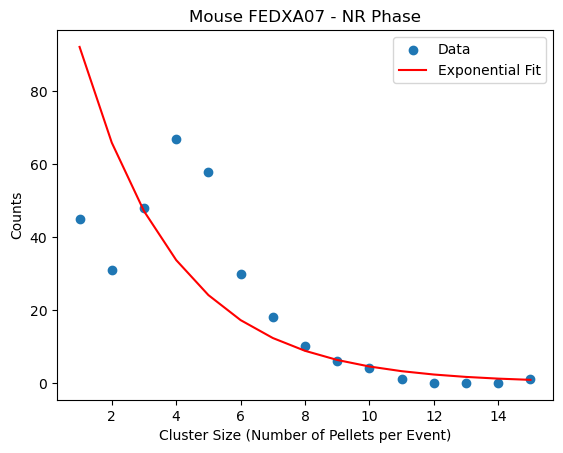

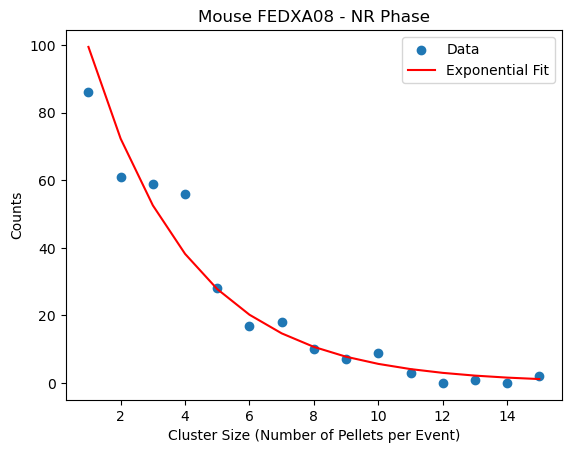

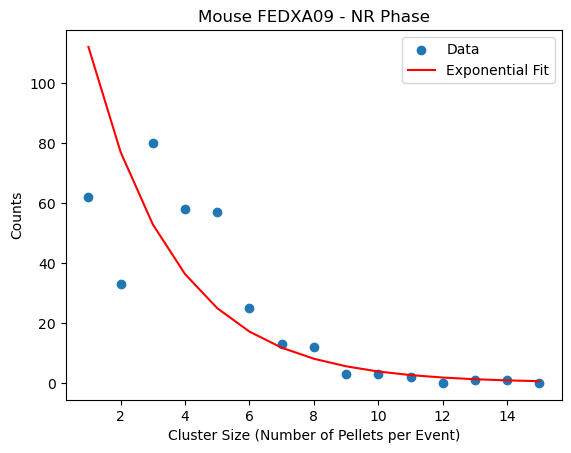

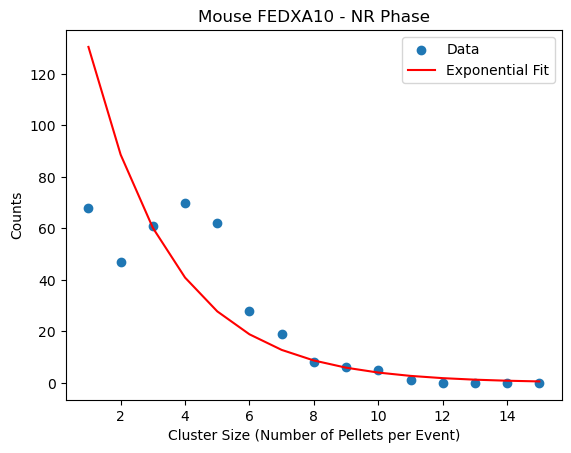

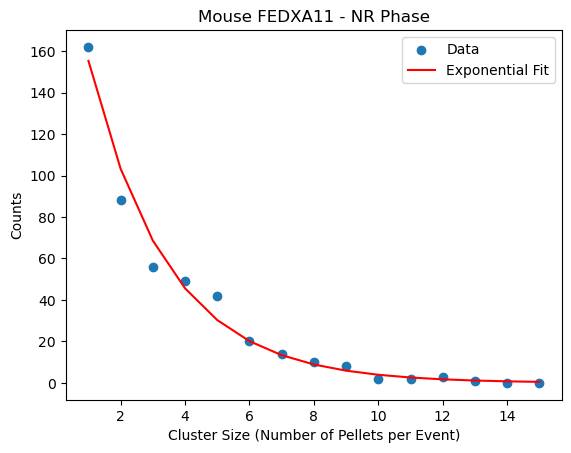

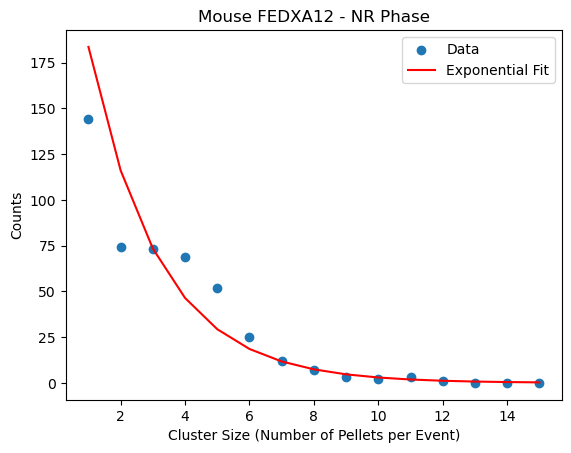

In [14]:
# Function to visualize cluster size distribution for selected mice
def visualize_cluster_size_distribution_selected(mice, selectors, phase='nr', max_pellets_per_event=15, save_plots=False):
    # Get the list of mice IDs that match the selectors
    selected_mice = get_data_subset(mice, selectors, verbose=False)
    print(f"Number of mice selected: {len(selected_mice)}")
    for mouse_id in selected_mice:
        exp_params = mice[mouse_id].get(f'exp_fit_params_{phase}', None)
        if exp_params:
            a = exp_params['a']
            b = exp_params['b']
            pellettimes = mice[mouse_id].get(f"{phase}_timestamps", [])
            if not pellettimes:
                continue
            # Get cluster sizes and counts
            cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
            sizes, counts = get_cluster_size_counts(cluster_sizes, max_pellets_per_event)
            # Plot
            plt.figure()
            plt.scatter(sizes, counts, label='Data')
            plt.plot(sizes, exponential_decay(sizes, a, b), label='Exponential Fit', color='red')
            plt.xlabel('Cluster Size (Number of Pellets per Event)')
            plt.ylabel('Counts')
            plt.title(f'Mouse {mouse_id} - NR Phase')
            plt.legend()
            if save_plots:
                # Save the plot to a file
                filename = f"Mouse_{mouse_id}_NR_Cluster_Size_Distribution.png"
                plt.savefig(filename)
                plt.close()
            else:
                # Display the plot
                plt.show()
        else:
            print(f"No exponential fit parameters for mouse {mouse_id} in NR phase.")

# Define the selectors for male mice in Order 1
selectors = {'sex': 'M', 'order': 1}

# Call the function to visualize the cluster size distributions
visualize_cluster_size_distribution_selected(mice, selectors, phase='nr', save_plots=False)


In [15]:
# Function to visualize combined cluster size distribution for selected mice on the same plot
def visualize_combined_cluster_size_distribution(mice, selectors, phase='nr', max_pellets_per_event=25, save_plot=False):
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np

    # Get the list of mice IDs that match the selectors
    selected_mice = get_data_subset(mice, selectors, verbose=False)
    num_mice = len(selected_mice)
    print(f"Number of mice selected: {num_mice}")

    if num_mice == 0:
        print("No mice match the selectors.")
        return

    # Create a colormap to assign different colors to each mouse
    color_map = cm.get_cmap('hsv', num_mice)

    plt.figure(figsize=(10, 6))

    for idx, mouse_id in enumerate(selected_mice):
        exp_params = mice[mouse_id].get(f'exp_fit_params_{phase}', None)
        if exp_params:
            a = exp_params['a']
            b = exp_params['b']
            pellettimes = mice[mouse_id].get(f"{phase}_timestamps", [])
            if not pellettimes:
                continue

            # Get cluster sizes and counts
            cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
            sizes, counts = get_cluster_size_counts(cluster_sizes, max_pellets_per_event)

            # Remove zeros to avoid plotting issues
            mask = counts > 0
            sizes = sizes[mask]
            counts = counts[mask]

            # Plot data for each mouse
            color = color_map(idx)
            plt.scatter(sizes, counts, label=f'Mouse {mouse_id} Data', color=color, alpha=0.7)
            plt.plot(sizes, exponential_decay(sizes, a, b), label=f'Mouse {mouse_id} Fit', color=color)
        else:
            print(f"No exponential fit parameters for mouse {mouse_id} in {phase.upper()} phase.")

    plt.xlabel('Cluster Size (Number of Pellets per Event)', fontsize=14)
    plt.ylabel('Counts', fontsize=14)
    plt.title(f'Cluster Size Distribution - Male Mice in Order 1 on {phase.upper()} Diet', fontsize=16)
    plt.legend()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.grid(False)
   

    if save_plot:
        # Save the plot to a file
        filename = f"Combined_Male_Order1_{phase.upper()}_Cluster_Size_Distribution.png"
        plt.savefig(filename)
        plt.close()
        print(f"Plot saved as {filename}")
    else:
        # Display the plot
        plt.show()


Number of mice selected: 6


C:\Users\hta031\AppData\Local\Temp\ipykernel_98540\3625840817.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap('hsv', num_mice)


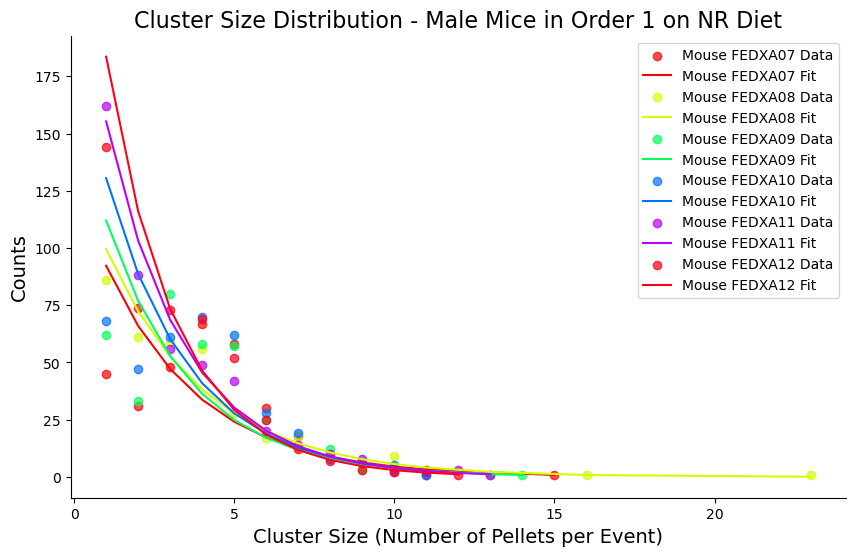

In [16]:
# Define the selectors for male mice in Order 1
selectors = {'sex': "M", 'order': 1}

# Call the function to visualize the combined cluster size distribution
visualize_combined_cluster_size_distribution(mice, selectors, phase='nr', save_plot=False)


Number of mice selected: 11


C:\Users\hta031\AppData\Local\Temp\ipykernel_98540\3625840817.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap('hsv', num_mice)


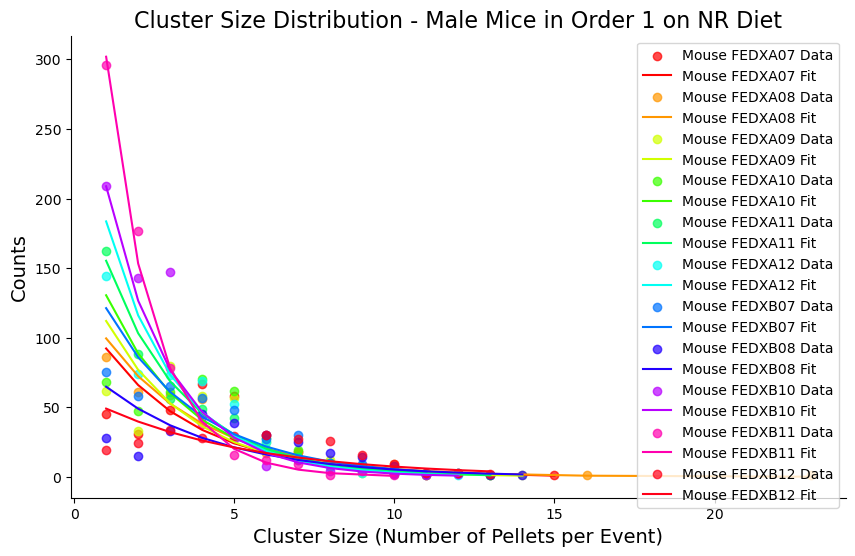

In [17]:
# Define the selectors for both male and female mice in Order 1
selectors = {'sex': ['M', 'F'], 'order': 1}
# Call the function to visualize the combined cluster size distribution
visualize_combined_cluster_size_distribution(mice, selectors, phase='nr', save_plot=False)


In [25]:
def get_combined_cluster_sizes(mice, selectors, phase='nr'):
    selected_mice = get_data_subset(mice, selectors, verbose=False)
    num_mice = len(selected_mice)
    print(f"Number of mice selected: {num_mice}")
    if num_mice == 0:
        print("No mice match the selectors.")
        return []
    combined_cluster_sizes = []
    for mouse_id in selected_mice:
        pellettimes = mice[mouse_id].get(f"{phase}_timestamps", [])
        if not pellettimes:
            continue
        cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
        combined_cluster_sizes.extend(cluster_sizes)
    return combined_cluster_sizes


Number of mice selected: 11
Fitted parameters: a=2254.607186079167, b=0.41939444266190523


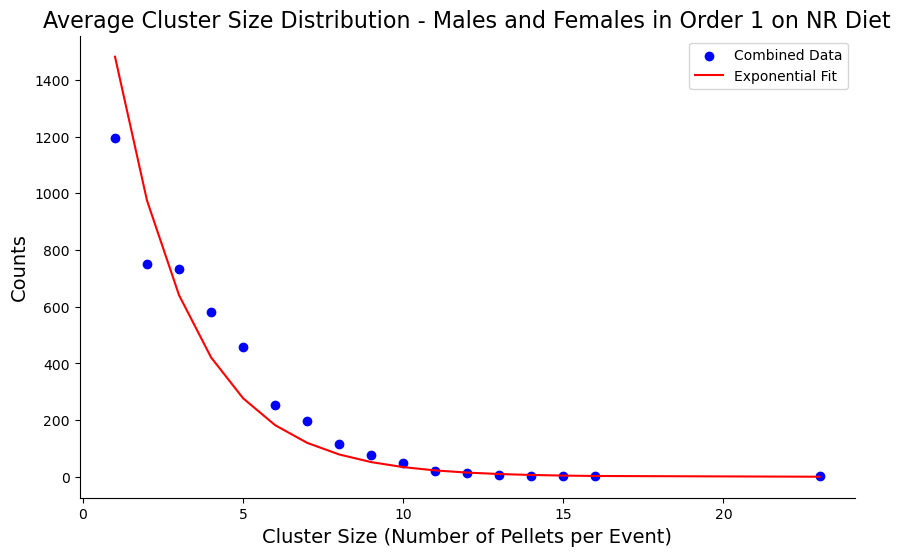

In [26]:
phase = 'nr'
# Collect combined cluster sizes
combined_cluster_sizes = get_combined_cluster_sizes(mice, selectors, phase='nr')

if not combined_cluster_sizes:
    print("No cluster size data available for the selected mice.")
else:
    # Compute counts
    max_pellets_per_event = 25
    sizes, counts = get_cluster_size_counts(combined_cluster_sizes, max_pellets_per_event)

    # Fit exponential decay model
    params, pcov = fit_exponential_decay(sizes, counts)
    if params is not None:
        a, b = params
        print(f"Fitted parameters: a={a}, b={b}")

        # Plot the combined cluster size distribution and exponential decay fit
        # Remove zeros to avoid plotting issues
        mask = counts > 0
        sizes = sizes[mask]
        counts = counts[mask]

        plt.figure(figsize=(10, 6))
        plt.scatter(sizes, counts, label='Combined Data', color='blue')
        plt.plot(sizes, exponential_decay(sizes, a, b), label='Exponential Fit', color='red')
        plt.xlabel('Cluster Size (Number of Pellets per Event)', fontsize=14)
        plt.ylabel('Counts', fontsize=14)
        plt.title(f'Average Cluster Size Distribution - Males and Females in Order 1 on {phase.upper()} Diet', fontsize=16)
        plt.legend()
        plt.grid(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.grid(False)
        plt.show()
    else:
        print("Not enough data to fit the exponential decay model.")
        

# fixing the average plot issue

In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind, pearsonr
import pandas as pd

# ============================
# Data Processing Functions
# ============================

def get_data_subset(dictionary, selectors, verbose=True):
    """
    Select a subset of mice based on specified criteria.
    
    Parameters
    ----------
    dictionary : dict
        Dictionary containing data for each mouse.
    selectors : dict
        Dictionary of selection criteria (e.g., {"sex": "M", "order": 1}).
    verbose : bool
        If True, prints the number of selected mice.
    
    Returns
    -------
    output_dictionary : dict
        Dictionary of selected mice.
    """
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in list(dictionary.keys()):
            try:
                if isinstance(value, list):
                    if output_dictionary[mouse_id][key] not in value:
                        del output_dictionary[mouse_id]
                else:
                    if output_dictionary[mouse_id][key] != value:
                        del output_dictionary[mouse_id]
            except KeyError:
                # If the key doesn't exist for a mouse, exclude it
                del output_dictionary[mouse_id]
    if verbose:
        print(f"{len(output_dictionary.keys())} mice selected based on selectors.")
    return output_dictionary

def cluster_pellets_by_ipi(pellettimes, ipi_threshold=60):
    """
    Cluster pellet events based on inter-pellet interval (IPI).
    
    Parameters
    ----------
    pellettimes : list of timestamps (in seconds)
        Times when each pellet was taken.
    ipi_threshold : float
        Threshold for defining clusters based on IPI (in seconds). Default is 60 seconds.
    
    Returns
    -------
    clusters : list of lists
        Each sublist contains the timestamps of pellets within a cluster.
    """
    if not pellettimes:
        return []
    
    pellettimes_sorted = sorted(pellettimes)
    clusters = []
    current_cluster = [pellettimes_sorted[0]]
    
    for i in range(1, len(pellettimes_sorted)):
        ipi = pellettimes_sorted[i] - pellettimes_sorted[i - 1]
        if ipi <= ipi_threshold:
            current_cluster.append(pellettimes_sorted[i])
        else:
            clusters.append(current_cluster)
            current_cluster = [pellettimes_sorted[i]]
    clusters.append(current_cluster)  # Add the last cluster
    
    return clusters

def get_cluster_size_distribution_for_mouse(pellettimes):
    """
    Get the cluster size distribution for a single mouse.
    
    Parameters
    ----------
    pellettimes : list of timestamps (in seconds)
        Times when each pellet was taken.
    
    Returns
    -------
    cluster_sizes : list
        The number of pellets in each cluster for this mouse.
    """
    clusters = cluster_pellets_by_ipi(pellettimes)
    cluster_sizes = [len(cluster) for cluster in clusters]
    return cluster_sizes

def get_combined_cluster_sizes(mice, selectors, phase='nr'):
    """
    Collect cluster sizes for each selected mouse.
    
    Parameters
    ----------
    mice : dict
        Dictionary containing data for each mouse.
    selectors : dict
        Dictionary of selection criteria.
    phase : str
        The dietary phase to analyze (e.g., 'nr').
    
    Returns
    -------
    combined_cluster_sizes : list of lists
        Each sublist contains cluster sizes for one mouse.
    """
    selected_mice = get_data_subset(mice, selectors, verbose=False)
    num_mice = len(selected_mice)
    print(f"Number of mice selected: {num_mice}")
    if num_mice == 0:
        print("No mice match the selectors.")
        return []
    combined_cluster_sizes = []
    for mouse_id, data in selected_mice.items():
        pellettimes = data.get(f"{phase}_timestamps", [])
        if not pellettimes:
            continue
        cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
        combined_cluster_sizes.append(cluster_sizes)
    return combined_cluster_sizes

def average_cluster_sizes_across_mice(pellettimes_group, max_pellets_per_event=25):
    """
    Calculate the average cluster size distribution across multiple mice.
    
    Parameters
    ----------
    pellettimes_group : list of lists
        A list of cluster size lists for each mouse.
    max_pellets_per_event : int
        The maximum number of pellets per event to include in the analysis.
    
    Returns
    -------
    avg_cluster_sizes : numpy array
        The average number of events for each cluster size (1 pellet, 2 pellets, etc.).
    """
    if not pellettimes_group:
        return np.zeros(max_pellets_per_event)
    
    total_cluster_counts = np.zeros(max_pellets_per_event)
    num_mice = len(pellettimes_group)
    
    for cluster_sizes in pellettimes_group:
        for size in cluster_sizes:
            if size <= max_pellets_per_event:
                total_cluster_counts[size - 1] += 1
            else:
                total_cluster_counts[-1] += 1  # Add to the last bin if exceeds
    
    avg_cluster_sizes = total_cluster_counts / num_mice
    return avg_cluster_sizes

def exponential_decay(x, a, b):
    """
    Exponential decay function.
    
    Parameters
    ----------
    x : array-like
        Independent variable.
    a : float
        Scale parameter.
    b : float
        Decay rate parameter.
    
    Returns
    -------
    y : array-like
        Dependent variable.
    """
    return a * np.exp(-b * x)

def fit_exponential_decay(sizes, counts):
    """
    Fit an exponential decay model to the data.
    
    Parameters
    ----------
    sizes : array-like
        Cluster sizes.
    counts : array-like
        Counts corresponding to each cluster size.
    
    Returns
    -------
    popt : tuple or None
        Optimal values for the parameters (a, b). None if fit fails.
    pcov : 2D array or None
        The estimated covariance of popt. None if fit fails.
    """
    # Remove zeros to avoid log(0)
    mask = counts > 0
    sizes = sizes[mask]
    counts = counts[mask]

    if len(sizes) < 2:
        # Not enough data to fit
        return None, None

    # Fit exponential decay
    try:
        popt, pcov = curve_fit(exponential_decay, sizes, counts, p0=(max(counts), 0.1))
        return popt, pcov
    except RuntimeError:
        return None, None

def get_cluster_size_counts(cluster_sizes, max_pellets_per_event=25):
    """
    Get counts for each cluster size.
    
    Parameters
    ----------
    cluster_sizes : list
        List of cluster sizes.
    max_pellets_per_event : int
        Maximum number of pellets per event.
    
    Returns
    -------
    sizes : numpy array
        Array of cluster sizes.
    counts : numpy array
        Array of counts corresponding to each cluster size.
    """
    sizes = np.arange(1, max_pellets_per_event + 1)
    counts = np.zeros_like(sizes, dtype=int)
    for size in cluster_sizes:
        if size <= max_pellets_per_event:
            counts[size - 1] += 1
        else:
            counts[-1] += 1
    return sizes, counts


In [28]:
def visualize_average_cluster_size_distribution(mice, selectors, phase='nr', max_pellets_per_event=25, save_plot=False):
    """
    Visualize the average cluster size distribution for selected mice.
    
    Parameters
    ----------
    mice : dict
        Dictionary containing data for each mouse.
    selectors : dict
        Dictionary of selection criteria (e.g., {"sex": ["M", "F"], "order": 1}).
    phase : str
        The dietary phase to analyze (e.g., 'nr').
    max_pellets_per_event : int
        The maximum number of pellets per event to include in the analysis.
    save_plot : bool
        If True, saves the plot as a PNG file. Otherwise, displays the plot.
    """
    # Step 1: Collect combined cluster sizes
    combined_cluster_sizes = get_combined_cluster_sizes(mice, selectors, phase=phase)
    
    if not combined_cluster_sizes:
        print("No cluster size data available for the selected mice.")
        return
    
    # Step 2: Compute average cluster size distribution across mice
    avg_cluster_sizes = average_cluster_sizes_across_mice(combined_cluster_sizes, max_pellets_per_event=max_pellets_per_event)
    
    # Step 3: Define cluster sizes
    sizes = np.arange(1, max_pellets_per_event + 1)
    counts = avg_cluster_sizes  # Average counts per cluster size
    
    # Optional: Print average cluster sizes for verification
    # print(f"Average Cluster Sizes: {avg_cluster_sizes}")
    
    # Step 4: Fit exponential decay model to average counts
    params, pcov = fit_exponential_decay(sizes, counts)
    if params is not None:
        a, b = params
        print(f"Fitted parameters: a={a:.2f}, b={b:.2f}")
    
        # Step 5: Remove zeros to avoid plotting issues
        mask = counts > 0
        sizes_plot = sizes[mask]
        counts_plot = counts[mask]
    
        # Step 6: Plot the average cluster size distribution and exponential decay fit
        plt.figure(figsize=(10, 6))
        plt.scatter(sizes_plot, counts_plot, label='Pellets', color='blue')
        plt.plot(sizes_plot, exponential_decay(sizes_plot, a, b), label='Exponential Fit', color='red')
        plt.xlabel('Cluster Size (Number of Pellets per Event)', fontsize=14)
        plt.ylabel('Average Counts', fontsize=14)
        plt.title(f'Average Cluster Size Distribution - Order 1 on {phase.upper()} Diet', fontsize=16)
        plt.legend()
        plt.grid(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        
        if save_plot:
            # Save the plot to a file
            filename = f"Average_Order1_{phase.upper()}_Cluster_Size_Distribution.png"
            plt.savefig(filename)
            plt.close()
            print(f"Plot saved as {filename}")
        else:
            # Display the plot
            plt.show()
    else:
        print("Not enough data to fit the exponential decay model.")


Number of mice selected: 11
Fitted parameters: a=142.74, b=0.29


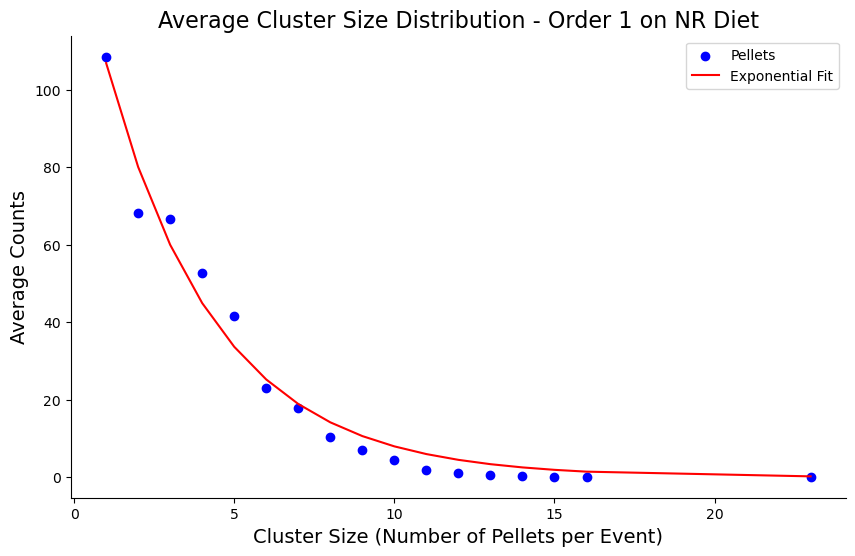

In [29]:
# Define the selectors for both male and female mice in Order 1
selectors = {'sex': ['M', 'F'], 'order': 1}

# Call the function to visualize the average cluster size distribution
visualize_average_cluster_size_distribution(
    mice=mice, 
    selectors=selectors, 
    phase='nr', 
    max_pellets_per_event=25, 
    save_plot=False  # Set to True if you want to save the plot
)


Number of mice selected: 12
Fitted parameters: a=350.96, b=0.45


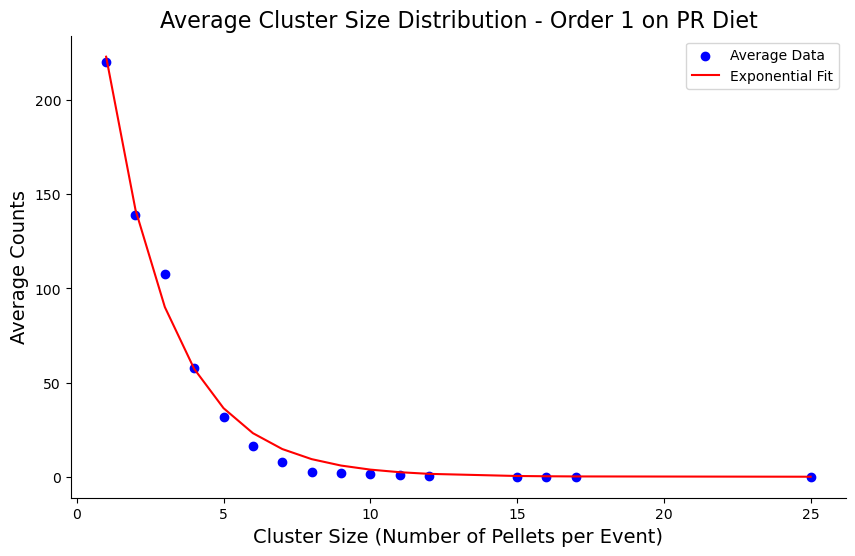

In [27]:
# Define the selectors for both male and female mice in Order 1
selectors = {'sex': ['M', 'F'], 'order': 2}

# Call the function to visualize the average cluster size distribution
visualize_average_cluster_size_distribution(
    mice=mice, 
    selectors=selectors, 
    phase='pr', 
    max_pellets_per_event=25, 
    save_plot=False  # Set to True if you want to save the plot
)
